In [53]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [54]:
class BMIstate(TypedDict):
    weight: float
    height: float
    bmi: float
    recommendation: str

In [55]:
def calculate_bmi(state: BMIstate) -> BMIstate:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    return {'bmi': bmi}

In [56]:
def recommendation_bmi(state: BMIstate) -> BMIstate:
    bmi =state['bmi']
    if bmi < 18.5:
        recommendation = "Underweight - Consider healthy weight gain"
    elif 18.5 <= bmi < 24.9:
        recommendation = "Normal weight - Maintain current healthy lifestyle"
    elif 25 <= bmi < 29.9:  
        recommendation = "Overweight - Consider weight-management strategies"     
    else:
        recommendation = "Obese - Consider professional weight-management support"
    return {'recommendation': recommendation}

In [57]:
graph = StateGraph(BMIstate)
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('recommendation_bmi', recommendation_bmi)
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'recommendation_bmi')
graph.add_edge('recommendation_bmi', END)
workflow = graph.compile()

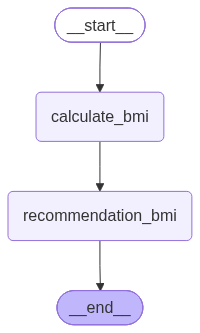

In [58]:
workflow

In [59]:
initial_state ={'weight': 70, 'height':1.75}

In [60]:
final_state = workflow.invoke(initial_state)

In [61]:
final_state

{'weight': 70,
 'height': 1.75,
 'bmi': 22.857142857142858,
 'recommendation': 'Normal weight - Maintain current healthy lifestyle'}

In [63]:
user_input = input("Enter your weight (kg) and height (m) separated by a space: ")
weight, height = map(float, user_input.split())
print(f"Your Weight: {weight} kg, Height: {height} m")
initial_state = {'weight': weight, 'height': height}
final_state = workflow.invoke(initial_state)
print(f"Your BMI is: {final_state['bmi']:.2f}")
print(f"Recommendation: {final_state['recommendation']}")

Your Weight: 55.0 kg, Height: 1.7 m
Your BMI is: 19.03
Recommendation: Normal weight - Maintain current healthy lifestyle
